In [1]:
import numpy as np
# from numpy import distutils
import matplotlib.pyplot as plt
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Palatino"],
    "font.size": 16,
})

%matplotlib inline

Generate sample data.
Their loci are scattered in two groups around exp(-3) and exp(0).
Their function values are following some power laws, though a coeffecient is highly uncertain.

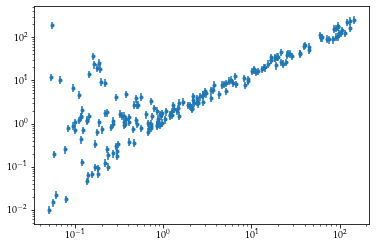

In [2]:
alim = 0.1
blim = 2.0
btrue = 1.0

Ns = 10
Ny = 20
x0, y0, e0 = [], [], []
for k in range(Ny):
    tempx = 5.0 * np.random.rand(int(Ns/2))
    tempx = np.append(tempx, -3.0 * np.random.rand(int(Ns/2)) )
    tempx = np.exp(tempx)

    a = 2.0 * np.random.rand() - 1.0
    a *= alim
    b1 = 2.0 * np.random.rand() - 1.0
    b1 *= blim

    tempy = np.exp(a) * tempx**btrue
    mask = tempx < 1.0
    tempy[mask] = np.exp(a) * tempx[mask]**b1
    tempy *= 1.0 + 1.0 * np.random.rand(Ns)
    
    tempe = tempy * 0.2
    
    x0 = np.append(x0,tempx)
    y0 = np.append(y0,tempy)
    e0 = np.append(e0,tempe)
    
# x0 = x0.reshape(-1,1)
# y0 = y0.reshape(-1,1)

# print(x0.shape,y0.shape,e0.shape)
plt.figure(1)
plt.errorbar(x0,y0,yerr=e0,fmt='.')
# plt.loglog(x0,y0,'.')
plt.xscale('log')
plt.yscale('log')

Construct model log probability functions.

In [3]:
def model_f(theta,x):
    a, b1, b2 = theta
    y = np.exp( a + b1 * np.log(x) )
    mask = x > 1.0
    y[mask] = np.exp( a + b2 * np.log(x[mask]) )
    return y

def log_prior(theta):
    return 0.0
    
def log_likelihood(theta, x, y, yerr):
    # compute log-normal probability
    logModel = np.log( model_f(theta,x) )
    sigma2 = np.log(1.0 + yerr / y) ** 2

    return - 0.5 * np.sum( (np.log(y) - logModel) ** 2 / sigma2 + np.log(2.0*np.pi*sigma2))

def log_posterior(theta, x, y, yerr):
    lp = log_prior(theta)
    lk = log_likelihood(theta, x, y, yerr)
    if (not np.isfinite(lp)) or (not np.isfinite(lk)):
        return - np.inf
    return lp + lk

In [ ]:
theta_ref = np.array([0.0, 0.0, 0.0])

import emcee
nwalkers = 32
ndim = len(theta_ref)
pos = 0.1 * np.random.randn(nwalkers,ndim)

sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_posterior, args=(x0, y0, e0)
)
sampler.run_mcmc(pos, 5000, progress=True);

 15%|█████▎                             | 751/5000 [00:08<00:47, 89.70it/s]

In [ ]:
tau = sampler.get_autocorr_time()
print(tau)

In [ ]:
flat_samples = sampler.get_chain(discard=70, thin=20, flat=True)
print(flat_samples.shape)

In [ ]:
import corner

fig = corner.corner(flat_samples);

Even though data around x~exp(-3) are scattered and somewhat contradicting to each others,
standard Bayesian inferance cannot capture this as uncertainty.

In [ ]:
inds = np.random.randint(len(flat_samples), size=1000)
for ind in inds:
    sample = flat_samples[ind]
    plt.plot(np.sort(x0), model_f(sample,np.sort(x0)), alpha=0.1)
plt.errorbar(x0,y0,yerr=e0,fmt='.')
plt.xscale('log')
plt.yscale('log')

# trial 1
What if data have a larger uncertainty?

In [ ]:
e1 = np.copy(e0)
mask = np.log(x0) < -1.0
e1[mask] *= 10.0

plt.figure(1)
plt.errorbar(x0,y0,yerr=e1,fmt='.')
plt.xscale('log')
plt.yscale('log')

In [ ]:
theta_ref = np.array([0.0, 0.0])

import emcee
nwalkers = 32
ndim = len(theta_ref)
pos = 0.1 * np.random.randn(nwalkers,ndim)

sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_posterior, args=(x0, y0, e1)
)
sampler.run_mcmc(pos, 5000, progress=True);

In [ ]:
tau = sampler.get_autocorr_time()
print(tau)

In [ ]:
flat_samples = sampler.get_chain(discard=60, thin=15, flat=True)
print(flat_samples.shape)

import corner

fig = corner.corner(flat_samples);

Sample models are now a bit more scattered.
However, the difference is very little compared to ten times larger standard deviation.
Also, Not so much justification on amplifying factor.

In [ ]:
inds = np.random.randint(len(flat_samples), size=1000)
for ind in inds:
    sample = flat_samples[ind]
    plt.plot(x0, model_f(sample,x0), alpha=0.1)
plt.errorbar(x0,y0,yerr=e1,fmt='.')
plt.xscale('log')
plt.yscale('log')

# A minimal example

Let's do a very simple Bayesian inference.

In [ ]:
def log_prior(theta):
    return 0.0
#     theta_ref = 0.0
#     sigma2 = 0.1
#     return - 0.5 * np.sum( (theta - theta_ref) ** 2 / sigma2 + np.log(2.0*np.pi*sigma2))
    
def log_likelihood(theta, theta_sample, theta_sample_error):
    sigma2 = theta_sample_error ** 2
    
#     ff1 = - 0.5 * (theta_sample - theta) ** 2 / sigma2 - 0.5 * np.log(2.0*np.pi*sigma2)
#     ff1 = np.sum( np.exp(ff1) )
#     return np.log(ff1)

    return - 0.5 * np.sum( (theta_sample - theta) ** 2 / sigma2 + np.log(2.0*np.pi*sigma2))

def log_posterior(theta, theta_sample, theta_sample_error):
    lp = log_prior(theta)
    lk = log_likelihood(theta, theta_sample, theta_sample_error)
    if (not np.isfinite(lp)) or (not np.isfinite(lk)):
        return - np.inf
    return lp + lk

In [ ]:
N = 1000
theta_sample = 0.3 * np.random.normal(size=(N,))
theta_sample[int(N/2):] += 5.0
theta_error = 0.3 * np.ones(N)

plt.figure(1)
plt.hist(theta_sample)

In [ ]:
theta_ref = 0.0

import emcee
nwalkers = 32
ndim = 1
pos = 2.5 + 5.0 * np.random.randn(nwalkers,ndim)

sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_posterior, args=(theta_sample,theta_error)
)
sampler.run_mcmc(pos, 5000, progress=True);

In [ ]:
tau = sampler.get_autocorr_time()
print(tau) 

In [ ]:
flat_samples = sampler.get_chain(discard=60, thin=15, flat=True)
print(flat_samples.shape)

import corner

# fig = corner.corner(flat_samples);
Nbins = 50

hist, bin_edges = np.histogram(flat_samples, bins=Nbins, density=True)

hist1, bin_edges1 = np.histogram(theta_sample, bins=Nbins, density=True)

xx = np.linspace (-2, 7, 500)
dx = np.diff(xx)[0]
sigma2 = 0.3 * 0.3
ff = - 0.5 * (xx - 5.0) ** 2 / sigma2 - 0.5 * np.log(2.0*np.pi*sigma2)
ff = np.exp(ff)

import numpy.matlib
xx_rep = np.matlib.repmat(xx,N,1)
theta_rep = np.transpose(np.matlib.repmat(theta_sample,500,1))

ff = - 0.5 * np.sum( (theta_rep - xx_rep) ** 2 / sigma2, axis=0 ) - 0.5 * np.log(2.0*np.pi*sigma2)
ff -= max(ff)

ff1 = - 0.5 * (theta_rep - xx_rep) ** 2 / sigma2 - 0.5 * np.log(2.0*np.pi*sigma2)
ff1 = np.sum( np.exp(ff1), axis=0 )
ff1 /= np.sum( ff1 ) * dx

ss2 = 2.5 ** 2 + 0.3 ** 2
ff2 = - 0.5 * (2.5 - xx) ** 2 / ss2 - 0.5 * np.log(2.0*np.pi*ss2)
ff2 = np.exp(ff2)
ff2 /= np.sum( ff2 ) * dx

plt.figure(2)
plt.plot(xx,ff1,'-r')

ff = np.exp(ff)

plt.figure(1)
plt.plot(bin_edges[:-1] + 0.5*np.diff(bin_edges), hist,'-k')
plt.plot(bin_edges1[:-1] + 0.5*np.diff(bin_edges1), hist1,'--')
plt.ylim([0, 1])

plt.figure(3)
plt.plot(xx, ff, '-r')
plt.plot(xx, ff1, '-b')
plt.plot(xx, ff2, '-g')

# A unified probability evaluation via Krigging

In [ ]:
import gstools as gs

xlog = np.log(x0)
elog = np.log( 1.0 + e1/y0 )
ylog = np.log(y0)

plt.figure(1)
plt.errorbar(xlog,ylog,yerr=elog,fmt='.')

bins = gs.variogram.standard_bins(xlog)
bin_center, gamma = gs.vario_estimate(xlog,ylog,bin_edges=bins)

models = {
    "Gaussian": gs.Gaussian,
    "Exponential": gs.Exponential,
    "Matern": gs.Matern,
    "Stable": gs.Stable,
    "Rational": gs.Rational,
    "Circular": gs.Circular,
    "Spherical": gs.Spherical,
    "SuperSpherical": gs.SuperSpherical,
    "JBessel": gs.JBessel,
}
scores = {}

plt.figure(2)
# plot the estimated variogram
plt.scatter(bin_center, gamma, color="k", label="data")
ax = plt.gca()

# fit all models to the estimated variogram
# for modelType in models:
modelType = "Gaussian"
fit_model = models[modelType](dim=1)
#     fit_model.set_arg_bounds(nugget=[1.0,5.0],len_scale=[0.,3.])
para, pcov, r2 = fit_model.fit_variogram(bin_center, gamma, return_r2=True)
fit_model.plot(x_max=4, ax=ax)
scores[modelType] = r2
    
print(para)
# fit_model.plot(x_max=3, ax=ax)
model = models[modelType](dim=1, **para)


In [ ]:
krig = gs.Krige(
    model=model,
    cond_pos=xlog,
    cond_val=ylog,
#     mean=1,
#     unbiased=False,
    exact=False,
    cond_err=elog,
)

# resulting grid
gridx = np.linspace(-3,5, 201)
krig(gridx)

In [ ]:
# ax = krig.plot()
plt.figure(1)
plt.loglog(np.exp(gridx),np.exp(krig.field),'-')
plt.scatter(x0, y0, color="k", zorder=10, label="Conditions")
plt.fill_between(
    np.exp(gridx),
    # plus/minus standard deviation (70 percent confidence interval)
    np.exp(krig.field - np.sqrt(krig.krige_var)),
    np.exp(krig.field + np.sqrt(krig.krige_var)),
    alpha=0.3,
    label="Standard deviation",
)
ax.legend()
plt.xscale('log')
plt.yscale('log')
# plt.ylim([1e-25, 1e-20])
# plt.xlim(np.exp([min(Wn[:,0])-fit_model.len_scale, max(Wn[:,0])+fit_model.len_scale]))

# krig_data = np.array([gridx,krig.field,np.sqrt(krig.krige_var)])
# filename = '../crs-exp/excitation-level1/crs.krig.txt'
# np.savetxt(filename,krig_data.T,fmt='%.15E',delimiter=' ')

Kriging (Gaussian process regression) looks sound; however, simply using a stationary kernel for covariance cannot represent these data.

In [ ]:
import sklearn.gaussian_process.kernels as kernels
from custom_kernels import Tanh

# test = 3.0 + (-1) * Tanh( 0.5 * kernels.DotProduct() )
test = kernels.RBF(length_scale_bounds=[-1e-1,1e4])
for param in test.hyperparameters: print(param)
# for param in test.get_params(): print(param)


In [ ]:
xlog, ylog = np.log(x0), np.log(y0)

from sklearn.gaussian_process import GaussianProcessRegressor
gaussian_process = GaussianProcessRegressor(kernel=test, n_restarts_optimizer=0)
gaussian_process.fit(xlog,ylog)
gaussian_process.kernel_

In [ ]:
xtest = np.sort(np.transpose(x0)).reshape(-1,1)

mean_prediction, std_prediction = gaussian_process.predict(np.log(xtest), return_std=True)
# mean_prediction = np.transpose(mean_prediction)
xtest = np.squeeze(xtest)
mean_prediction = np.squeeze(mean_prediction)
print(xtest.shape, mean_prediction.shape, std_prediction.shape)

plt.scatter(x0, y0, label="Observations")
plt.loglog(xtest, np.exp(mean_prediction), label="Mean prediction")
plt.fill_between(
    xtest,
    np.exp(mean_prediction - 3.0 * std_prediction),
    np.exp(mean_prediction + 3.0 * std_prediction),
    alpha=0.5,
    label=r"95% confidence interval",
)
# plt.xscale('log')
# plt.yscale('log')
# plt.legend()
# plt.xlabel("$x$")
# plt.ylabel("$f(x)$")
# _ = plt.title("Gaussian process regression on noise-free dataset")

# GPR with a custom kernel via GPy

In [3]:
import GPy
from custom_kernels import TanhVar, TanhDiagVar

kb = TanhVar(1)

xt = x0.reshape(200,1)
k1 = GPy.kern.Exponential(input_dim=1, variance=10., lengthscale=1.)
KK = k1.K(xt,xt[:100])
print(KK.shape)

(200, 100)


gp.,value,constraints,priors
sum.rbf.variance,13.145765841707933,+ve,
sum.rbf.lengthscale,5.443054589815317,+ve,
sum.mul.Exponential.variance,1.130514402929975,+ve,
sum.mul.Exponential.lengthscale,1.0,+ve,
sum.mul.TanhVar.variance1,7.433629897409803e-10,+ve,
sum.mul.TanhVar.variance2,6.242058322873666,+ve,
sum.mul.TanhVar.slope,-1.7380891102962233,,
sum.mul.TanhVar.phase,-2.8757834873335226,,
het_Gauss.variance,"(200, 1)",+ve fixed,


(-10.0, 10.0)

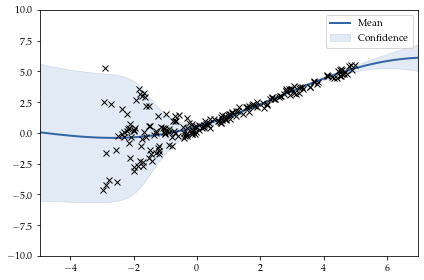

In [4]:
x0 = np.squeeze(x0)
y0 = np.squeeze(y0)

xlog = np.log(x0)
elog = np.log( 1.0 + e0/y0 )
ylog = np.log(y0)

k1 = GPy.kern.Exponential(input_dim=1, variance=10., lengthscale=1.)
k2 = GPy.kern.RBF(1)
k3 = GPy.kern.Matern32(1)
k4 = GPy.kern.Matern52(1)
kt = TanhDiagVar(1,var2=11.0,slope=-1.0)
kc1 = GPy.kern.Bias(1)
kc2 = GPy.kern.Bias(1)
kb = GPy.kern.Brownian(1)
kernel = k2 + k1 * kt

m = GPy.models.GPHeteroscedasticRegression(xlog[:,None],ylog[:,None],kernel)
m['.*het_Gauss.variance'] = abs(elog)[:,None] #Set the noise parameters to the error in Y
m.het_Gauss.variance.fix() #We can fix the noise term, since we already know it

# m = GPy.models.GPHeteroscedasticRegression(x0[:,None],ylog[:,None],kernel)
# m['.*het_Gauss.variance'] = abs(elog)[:,None] #Set the noise parameters to the error in Y
# m.het_Gauss.variance.fix() #We can fix the noise term, since we already know it

m.optimize(optimizer='bfgs',messages=True)

display(m)
# plt.figure(1)
# m.plot(plot_density=True)
# GPy.plotting.show(fig, filename='basic_gp_regression_density_notebook_optimized')

m.plot_f() #Show the predictive values of the GP.
# plt.errorbar(X,Y,yerr=np.array(m.likelihood.flattened_parameters).flatten(),fmt=None,ecolor='r',zorder=1)
# pb.grid()
plt.plot(xlog,ylog,'kx')
# plt.xlim([1e-2, 1e3])
plt.ylim([-10, 10])

# fig = m.plot(plot_density=True)
# GPy.plotting.show(fig, filename='basic_gp_regression_density_notebook_optimized')

# Bayesian inference with a Gaussian process noise

In [21]:
x0 = np.squeeze(x0)
y0 = np.squeeze(y0)

xlog = np.log(x0)
elog = np.log( 1.0 + e0/y0 )
ylog = np.log(y0)

xspan = np.amax(xlog) - np.amin(xlog)

xd2 = ( xlog[:,None] - xlog[:,None].T ) ** 2

def model_f(theta,x):
    a, b1, b2 = theta
    y = np.exp( a + b1 * np.log(x) )
    mask = x > 1.0
    y[mask] = np.exp( a + b2 * np.log(x[mask]) )
    return y

def model_cov_kernel(theta_K, x, x2=None):
    if x2 is None:
        x2 = x
    n1, n2 = len(x), len(x2)
    x = x[:,None]
    x2 = x2[:,None]

    N = 3
    K = np.zeros([n1,n2])
    for nk in range(N):
        var, phase = theta_K[2*nk:2*(nk+1)]
        K += var * np.diag( var * np.sin( 2.0 * np.pi * (x - phase) / xspan * nk ) )
        
    var, scale = theta_K[-2:]
#     xd = ( x - x2.T )
    K += var * np.exp( - xd2 / scale )
    return K

def log_prior(theta):
    return 0.0
    
def log_likelihood(theta, x, y, yerr):
    theta_m, theta_K = theta[:3], theta[3:]
    
    # compute log-normal probability
    logModel = np.log( model_f(theta_m,x) )
    dev = (np.log(y) - logModel)
    dev = dev[:,None]
    
    K = model_cov_kernel(theta_K,x,x)
    sigma2 = np.log(1.0 + yerr / y) ** 2
    K += np.diag(sigma2)

#     print(np.linalg.solve(K,dev).shape)
    return - 0.5 * np.sum ( dev * np.linalg.solve(K,dev) )

def log_posterior(theta, x, y, yerr):
    lp = log_prior(theta)
    lk = log_likelihood(theta, x, y, yerr)
    if (not np.isfinite(lp)) or (not np.isfinite(lk)):
        return - np.inf
    return lp + lk

In [22]:
theta_ref = np.ones(11)

import emcee
nwalkers = 32
ndim = len(theta_ref)
pos = theta_ref * (1.0 + 0.1 * np.random.randn(nwalkers,ndim))

sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_posterior, args=(x0, y0, e0)
)
sampler.run_mcmc(pos, 5000, progress=True);

  3%|█▏                                 | 174/5000 [00:58<30:51,  2.61it/s]Traceback (most recent call last):
  File "/opt/homebrew/lib/python3.9/site-packages/emcee/ensemble.py", line 624, in __call__
    return self.f(x, *self.args, **self.kwargs)
  File "/var/folders/y7/54kn6ltn4_l8nfwqq17qvxnm0000gq/T/ipykernel_4799/735944959.py", line 57, in log_posterior
    lk = log_likelihood(theta, x, y, yerr)
  File "/var/folders/y7/54kn6ltn4_l8nfwqq17qvxnm0000gq/T/ipykernel_4799/735944959.py", line 53, in log_likelihood
    return - 0.5 * np.sum ( dev * np.linalg.solve(K,dev) )
  File "<__array_function__ internals>", line 180, in solve
  File "/opt/homebrew/lib/python3.9/site-packages/numpy/linalg/linalg.py", line 393, in solve
    r = gufunc(a, b, signature=signature, extobj=extobj)
KeyboardInterrupt
  3%|█▏                                 | 174/5000 [00:58<26:59,  2.98it/s]

emcee: Exception while calling your likelihood function:
  params: [-52.15053072   7.56235406 -75.33618316 -21.30138069 106.46211005
  21.62772235  57.0533253   -3.29271594  31.62069996   7.88660318
 -10.354771  ]
  args: (array([3.55590483e+01, 1.26687655e+00, 1.50430592e+00, 8.16907393e+00,
       1.98843535e+00, 3.77529653e-01, 4.10983498e-01, 7.37985485e-01,
       1.42864289e-01, 1.15371488e-01, 1.18100226e+01, 2.08485139e+00,
       4.66111247e+00, 1.68446003e+01, 1.29920152e+02, 1.83925131e-01,
       9.27473135e-01, 2.38805870e-01, 8.61308324e-01, 4.12731303e-01,
       1.18054674e+00, 1.32275533e+02, 1.90437743e+01, 1.38452630e+01,
       6.13872901e+01, 2.99820993e-01, 1.83788446e-01, 4.62417151e-01,
       8.48874731e-01, 1.66911477e-01, 9.22356021e+01, 6.59647188e+00,
       5.10448092e+00, 3.70754340e+00, 6.24864478e+00, 1.76087923e-01,
       5.06520361e-01, 2.71281325e-01, 2.56209029e-01, 8.28277458e-02,
       3.99565082e+01, 1.68761389e+00, 1.03813308e+02, 9.18311491e+

KeyboardInterrupt: 